# π₀.₅ heterogeneous co-training — large public reproduction

Four sources share a randomly initialized, fully trainable autoregressive model: ALOHA and DROID action prediction, COCO captioning, and VQAv2. This is **multimodal** (images/text/state/action), **multi-task**, **multi-dataset**, and **multi-embodiment** (two robots).

Public OpenPI code supplies the adapters, FAST/PaliGemma tokenization, attention masking, and SigLIP/Gemma components. Model scaling, public-data mixture, padding, splits, and schedule are reproduction conventions. PI's proprietary household/mobile-manipulator and full cross-embodiment corpora, object-localization mixture, high-level semantic annotations, and verbal-instruction corpus are unavailable here.

### 1 · Configuration
Run in the same OpenPI environment as the reference. Set `PROJECT_ROOT` if needed. `large` is first; change only `MODEL_PRESET` to `small` for the known 69,732,864-parameter fallback. Fresh runs execute the smoke test and LR finder before real initialization. Existing checkpoints skip those temporary experiments and restore Adam in stage 10. Stop after stage 8 to inspect the LR plot and edit `PEAK_LR` in stage 9 before continuing.

In [1]:
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

from pathlib import Path
import gc
import hashlib
import json
import math
import time
import numpy as np
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
from IPython.display import display
from openpi import transforms
from openpi.models import tokenizer
from openpi.policies import aloha_policy, droid_policy
from openpi.training import config as training_config

PROJECT_ROOT = Path(os.environ.get("OPENPI_PROJECT_ROOT", "/home/osx/openpi")).expanduser()
DATA_ROOT = PROJECT_ROOT / "data/pi05_heterogeneous_large"
LEGACY_DATA_ROOT = PROJECT_ROOT / "data/pi05_heterogeneous"
DROID_RAW_DIR = PROJECT_ROOT / "data/droid_small"
DROID_CONVERTER = PROJECT_ROOT / "examples/droid/convert_droid_data_to_lerobot.py"
MODEL_PRESET = "large"                 # Explicit fallback: "small"; never automatic.
RUN_NAME = f"pi05_heterogeneous_{MODEL_PRESET}_overnight_v1"
RUN_DIR = DATA_ROOT / "runs" / RUN_NAME
DATA_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

ALOHA_REPO = "lerobot/aloha_static_screw_driver"
COCO_REPO = "jxie/coco_captions"
VQA_REPO = "merve/vqav2-small"
COCO_TRAIN_IMAGES, COCO_VAL_IMAGES = 10_000, 1_000
VQA_VAL_FRACTION = 0.10
ACTION_HORIZON = 50
COMMON_STATE_DIM = COMMON_ACTION_DIM = 14
MAX_TOKEN_LEN, VOCAB_SIZE, MODEL_IMAGE_SIZE = 288, 257_152, 224
BATCH_SIZE = 1
NUM_WORKERS, PREFETCH_EXAMPLES = 32, 64
SPLIT_SEED, TRAIN_SEED, VAL_SEED = 42, 20260920, 20260921
INIT_SEED, EMBED_SEED, SMOKE_SEED, LR_FINDER_SEED = 42, 1234, 701, 801

RUN_LR_FINDER = True
LR_MIN, LR_MAX, LR_FINDER_STEPS = 1e-6, 3e-3, 512
LR_SMOOTH_BETA, LR_LOG_EVERY, SMOKE_LR = 0.98, 50, 1e-4

# Step budget is editable without a notebook-imposed ceiling. The wall-clock
# budget pauses safely; rerun stage 11 to continue toward TOTAL_TRAIN_STEPS.
TOTAL_TRAIN_STEPS = 1_000_000
MAX_RUN_HOURS = 10.0                   # None: run until the step budget is met.
WARMUP_STEPS = 10_000
PEAK_LR = 1e-4                        # Provisional; inspect this model's LR finder.
FINAL_LR = 1e-6
VALIDATE_EVERY, CHECKPOINT_EVERY = 10_000, 25_000
VAL_EXAMPLES_PER_SOURCE = 128
LOG_EVERY, PLOT_EVERY, ROLLING_WINDOW = 100, 100, 100

assert MODEL_PRESET in ("large", "small") and BATCH_SIZE == 1
assert NUM_WORKERS > 0 and PREFETCH_EXAMPLES > 0
assert all(hasattr(obj, name) for obj, name in [
    (transforms, "Normalize"), (transforms, "PadStatesAndActions"),
    (transforms, "TokenizeFASTInputs"), (tokenizer, "FASTTokenizer"),
    (aloha_policy, "AlohaInputs"), (droid_policy, "DroidInputs"),
    (training_config, "LeRobotDROIDDataConfig"),
]), "Use the tested OpenPI checkout/environment."
assert any(d.platform == "gpu" for d in jax.devices()), "A CUDA JAX GPU is required."
print("Model:", MODEL_PRESET, "| devices:", jax.devices(), "| output:", RUN_DIR)
print("Workers/prefetch:", NUM_WORKERS, PREFETCH_EXAMPLES,
      "(throughput settings; do not alter the deterministic example stream)")


Model: large | devices: [CudaDevice(id=0)] | output: /home/osx/openpi/data/pi05_heterogeneous_large/runs/pi05_heterogeneous_large_overnight_v1
Workers/prefetch: 32 64 (throughput settings; do not alter the deterministic example stream)


## 2 · Data acquisition and held-out splits
Reuse robot caches, expand COCO until 11,000 unique IDs exist, and split all VQAv2-small rows deterministically. Source probabilities stay equal. COCO splitting prevents within-COCO image leakage; the specified VQA row split does not promise image disjointness across VQA rows or across web sources.

In [2]:
from dataclasses import dataclass
from functools import lru_cache
from typing import Optional
from collections import deque
from concurrent.futures import ThreadPoolExecutor
from threading import RLock
import hashlib
import importlib.util
import json
import os
import subprocess
import gc

from datasets import load_dataset, load_from_disk, concatenate_datasets
from huggingface_hub import snapshot_download
from PIL import Image
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset, HF_LEROBOT_HOME
from openpi import transforms
from openpi.models import tokenizer as openpi_tokenizer
from openpi.models import model as openpi_model
from openpi.policies import aloha_policy, droid_policy

DATA_ROOT.mkdir(parents=True, exist_ok=True)
DATASET_CACHE = DATA_ROOT / "datasets"
DATASET_CACHE.mkdir(parents=True, exist_ok=True)
ALOHA_TRAIN_EPISODES = list(range(40))
ALOHA_VAL_EPISODES = list(range(40, 50))
DROID_TRAIN_EPISODES = list(range(24))
DROID_VAL_EPISODES = list(range(24, 30))

# Preserve the cached snapshot and LeRobot import/conversion paths used in the reference.
ALOHA_DIR = Path(snapshot_download(repo_id=ALOHA_REPO, repo_type="dataset"))
assert any(ALOHA_DIR.rglob("*.parquet")) and any(ALOHA_DIR.rglob("*.mp4"))
assert DROID_CONVERTER.exists(), f"Missing tested converter: {DROID_CONVERTER}"
spec = importlib.util.spec_from_file_location("openpi_droid_converter", DROID_CONVERTER)
droid_converter = importlib.util.module_from_spec(spec)
spec.loader.exec_module(droid_converter)
DROID_LEROBOT_REPO = getattr(droid_converter, "REPO_NAME", "your_hf_username/my_droid_dataset")
DROID_LEROBOT_DIR = Path(HF_LEROBOT_HOME) / DROID_LEROBOT_REPO
droid_info = DROID_LEROBOT_DIR / "meta" / "info.json"
if not droid_info.exists():
    assert len(list(DROID_RAW_DIR.rglob("trajectory.h5"))) >= 30, (
        f"Restore the previously downloaded official 30-demo subset at {DROID_RAW_DIR}."
    )
    print("Creating the missing DROID LeRobot conversion once...")
    subprocess.run([
        "uv", "run", str(DROID_CONVERTER), "--data_dir", str(DROID_RAW_DIR)
    ], cwd=PROJECT_ROOT, check=True)
assert droid_info.exists(), f"Conversion not found: {DROID_LEROBOT_DIR}"
with droid_info.open() as handle:
    droid_metadata = json.load(handle)
assert int(droid_metadata["total_episodes"]) == 30, "Expected the tested official 30-demo DROID conversion."

# Cache disjoint incremental row ranges. The legacy cache is the first rows,
# exactly as acquired by the supplied notebook; it is never changed.
# HF can cache whole source shards internally even when a row slice is requested.
COCO_CACHE = DATASET_CACHE / "coco_expanded"
COCO_CACHE.mkdir(exist_ok=True)
coco_manifest_path = COCO_CACHE / "parts.json"
if coco_manifest_path.exists():
    coco_parts_manifest = json.loads(coco_manifest_path.read_text())
    assert coco_parts_manifest["repo"] == COCO_REPO
    coco_parts = [load_from_disk(p["path"]) for p in coco_parts_manifest["parts"]]
else:
    legacy_coco = LEGACY_DATA_ROOT / "coco_subset"
    coco_parts = []
    coco_parts_manifest = {"repo": COCO_REPO, "parts": []}
    if (legacy_coco / "state.json").exists():
        base = load_from_disk(str(legacy_coco))
        coco_parts.append(base)
        coco_parts_manifest["parts"].append({
            "path": str(legacy_coco.resolve()), "start": 0, "stop": len(base)
        })

def _persist_json_atomic(path, payload):
    temporary = path.with_name(path.name + ".tmp")
    temporary.write_text(json.dumps(payload, sort_keys=True, indent=2))
    os.replace(temporary, path)

needed_images = COCO_TRAIN_IMAGES + COCO_VAL_IMAGES
seen_coco_ids = {int(cid) for part in coco_parts for cid in part["cocoid"]}
next_coco_row = sum(len(part) for part in coco_parts)
while len(seen_coco_ids) < needed_images:
    # Each range is consumed once, with unique images verified after every batch.
    stop = next_coco_row + 5_000
    part_path = COCO_CACHE / f"rows_{next_coco_row:07d}_{stop:07d}"
    if (part_path / "state.json").exists():
        part = load_from_disk(str(part_path))
    else:
        part = load_dataset(COCO_REPO, split=f"train[{next_coco_row}:{stop}]")
        assert len(part), "COCO exhausted before reaching the requested unique-image count."
        temporary = part_path.with_name(part_path.name + ".incomplete")
        if temporary.exists():
            import shutil
            shutil.rmtree(temporary)
        part.save_to_disk(str(temporary))
        os.replace(temporary, part_path)
        part = load_from_disk(str(part_path))
    assert {"image", "caption", "cocoid"}.issubset(part.column_names)
    coco_parts.append(part)
    coco_parts_manifest["parts"].append({
        "path": str(part_path.resolve()), "start": next_coco_row,
        "stop": next_coco_row + len(part),
    })
    next_coco_row += len(part)
    seen_coco_ids.update(int(cid) for cid in part["cocoid"])
    _persist_json_atomic(coco_manifest_path, coco_parts_manifest)
    print(f"COCO cached: {next_coco_row:,} rows; {len(seen_coco_ids):,} unique images")
_persist_json_atomic(coco_manifest_path, coco_parts_manifest)
coco = coco_parts[0] if len(coco_parts) == 1 else concatenate_datasets(coco_parts)
assert len(seen_coco_ids) >= needed_images

VQA_CACHE = DATASET_CACHE / "vqav2_all"
if (VQA_CACHE / "state.json").exists():
    vqa = load_from_disk(str(VQA_CACHE))
else:
    # The tested source uses its `validation` split; all rows are divided locally.
    vqa = load_dataset(VQA_REPO, split="validation")
    temporary = VQA_CACHE.with_name(VQA_CACHE.name + ".incomplete")
    if temporary.exists():
        import shutil
        shutil.rmtree(temporary)
    vqa.save_to_disk(str(temporary))
    os.replace(temporary, VQA_CACHE)
    vqa = load_from_disk(str(VQA_CACHE))
assert {"image", "question", "multiple_choice_answer"}.issubset(vqa.column_names)
assert len(vqa) >= 18_000, "The full VQAv2-small split was not loaded."

unique_coco_ids = np.asarray(sorted(seen_coco_ids), dtype=np.int64)
np.random.default_rng(SPLIT_SEED).shuffle(unique_coco_ids)
COCO_TRAIN_IDS = set(unique_coco_ids[:COCO_TRAIN_IMAGES].tolist())
COCO_VAL_IDS = set(unique_coco_ids[COCO_TRAIN_IMAGES:needed_images].tolist())
assert COCO_TRAIN_IDS.isdisjoint(COCO_VAL_IDS)
COCO_TRAIN_INDICES = np.asarray([
    i for i, cid in enumerate(coco["cocoid"]) if int(cid) in COCO_TRAIN_IDS
], dtype=np.int32)
COCO_VAL_INDICES = np.asarray([
    i for i, cid in enumerate(coco["cocoid"]) if int(cid) in COCO_VAL_IDS
], dtype=np.int32)
vqa_indices = np.random.default_rng(SPLIT_SEED + 1).permutation(len(vqa))
n_vqa_val = max(1, round(len(vqa) * VQA_VAL_FRACTION))
VQA_TRAIN_INDICES = vqa_indices[:-n_vqa_val]
VQA_VAL_INDICES = vqa_indices[-n_vqa_val:]
assert not np.intersect1d(VQA_TRAIN_INDICES, VQA_VAL_INDICES).size

# Actual IDs and row indices are recorded, not merely counts or a split seed.
dataset_manifest = {
    "schema": 1, "split_seed": SPLIT_SEED,
    "aloha": {"repo": ALOHA_REPO, "snapshot": str(ALOHA_DIR.resolve()),
              "train_episodes": ALOHA_TRAIN_EPISODES, "val_episodes": ALOHA_VAL_EPISODES},
    "droid": {"repo": DROID_LEROBOT_REPO, "path": str(DROID_LEROBOT_DIR.resolve()),
              "train_episodes": DROID_TRAIN_EPISODES, "val_episodes": DROID_VAL_EPISODES,
              "metadata_hashes": {str(p.relative_to(DROID_LEROBOT_DIR)): hashlib.sha256(p.read_bytes()).hexdigest()
                                  for p in sorted((DROID_LEROBOT_DIR / "meta").glob("*.json*"))}},
    "coco": {"repo": COCO_REPO, "parts": coco_parts_manifest["parts"],
             "part_fingerprints": [part._fingerprint for part in coco_parts],
             "train_image_ids": sorted(COCO_TRAIN_IDS), "val_image_ids": sorted(COCO_VAL_IDS)},
    "vqav2": {"repo": VQA_REPO, "fingerprint": vqa._fingerprint,
              "train_rows": VQA_TRAIN_INDICES.tolist(), "val_rows": VQA_VAL_INDICES.tolist()},
}
_persist_json_atomic(DATA_ROOT / "dataset_manifest.json", dataset_manifest)
print(f"ALOHA: 40/10 episodes; DROID: 24/6 converted episodes")
print(f"COCO: {len(COCO_TRAIN_IDS):,}/{len(COCO_VAL_IDS):,} unique train/val images")
print(f"VQAv2: {len(VQA_TRAIN_INDICES):,}/{len(VQA_VAL_INDICES):,} train/val rows")


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/182 [00:00<?, ?it/s]

Saving the dataset (0/2 shards):   0%|          | 0/5000 [00:00<?, ? examples/s]

COCO cached: 17,000 rows; 3,397 unique images


Resolving data files:   0%|          | 0/182 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/182 [00:00<?, ?it/s]

Saving the dataset (0/2 shards):   0%|          | 0/5000 [00:00<?, ? examples/s]

COCO cached: 57,000 rows; 11,391 unique images


Saving the dataset (0/7 shards):   0%|          | 0/21435 [00:00<?, ? examples/s]

ALOHA: 40/10 episodes; DROID: 24/6 converted episodes
COCO: 10,000/1,000 unique train/val images
VQAv2: 19,291/2,144 train/val rows


## 3 · Training-only normalization
ALOHA statistics are recomputed for episodes 0–39 in PI joint/gripper conventions. DROID statistics use converted training episodes 0–23 in native 8-D space; both caches record their exact provenance. Quantiles include the same clipped-end 50-step action chunks used for training.

In [3]:
# Helpers are copied from the tested notebook; no image decoding for statistics.
def as_numpy(x):
    if hasattr(x, 'detach'):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def future_action_chunks(actions, horizon=50):
    """
    Convert a trajectory [T,D] into future chunks [T,H,D].

    At the end of an episode, repeat the final action so every
    training example still has a fixed 50-step target.
    """
    T = actions.shape[0]
    indices = np.arange(T)[:, None] + np.arange(horizon)[None, :]
    indices = np.clip(indices, 0, T - 1)
    return actions[indices]

def quantile_stats(x):
    x = np.asarray(x, dtype=np.float32)
    return {
        'q01': np.quantile(x, 0.01, axis=0).astype(np.float32),
        'q99': np.quantile(x, 0.99, axis=0).astype(np.float32),
    }

def quantile_normalize(x, q01, q99):
    """
    Same q01/q99 mapping used by OpenPI Normalize:

        q01 -> -1
        q99 -> +1
    """
    x = np.asarray(x, dtype=np.float32)
    return (x - q01) / (q99 - q01 + 1e-06) * 2.0 - 1.0

NORM_CACHE = DATA_ROOT / "normalization"
NORM_CACHE.mkdir(exist_ok=True)

def _norm_cache(source, provenance, compute):
    canonical = json.dumps(provenance, sort_keys=True, separators=(",", ":"))
    key = hashlib.sha256(canonical.encode()).hexdigest()[:20]
    path = NORM_CACHE / f"{source}_{key}.npz"
    if path.exists():
        with np.load(path, allow_pickle=False) as stored:
            assert stored["provenance"].item() == canonical
            result = {key: stored[key].copy() for key in ("state_q01", "state_q99", "action_q01", "action_q99")}
    else:
        print(f"Computing {source} training-only q01/q99...")
        result = compute()
        temporary = path.with_name(path.name + ".tmp")
        with temporary.open("wb") as handle:
            np.savez(handle, provenance=np.asarray(canonical), **result)
            handle.flush()
            os.fsync(handle.fileno())
        os.replace(temporary, path)
    return result, path

def _collect_stats(state_arrays, action_arrays):
    # Same scalar-q calls as the reference, one dimension at a time, avoiding
    # another full 40-episode action-chunk matrix during quantile computation.
    def column_quantiles(arrays):
        width = arrays[0].shape[1]
        q01, q99 = [], []
        for dim in range(width):
            column = np.concatenate([a[:, dim] for a in arrays])
            stats = quantile_stats(column)
            q01.append(stats["q01"])
            q99.append(stats["q99"])
        arrays.clear()
        return np.asarray(q01, dtype=np.float32), np.asarray(q99, dtype=np.float32)
    state_q01, state_q99 = column_quantiles(state_arrays)
    action_q01, action_q99 = column_quantiles(action_arrays)
    return {"state_q01": state_q01, "state_q99": state_q99,
            "action_q01": action_q01, "action_q99": action_q99}

def _compute_aloha_stats():
    states_all, actions_all = [], []
    delta_mask = np.asarray(transforms.make_bool_mask(6, -1, 6, -1), dtype=bool)
    for episode_index in ALOHA_TRAIN_EPISODES:
        ds = LeRobotDataset(repo_id=ALOHA_REPO, root=ALOHA_DIR, episodes=[episode_index])
        raw_states = np.stack([as_numpy(x) for x in ds.hf_dataset["observation.state"]]).astype(np.float32)
        raw_actions = np.stack([as_numpy(x) for x in ds.hf_dataset["action"]]).astype(np.float32)
        states_pi = np.stack([aloha_policy._decode_state(
            state.copy(),
            adapt_to_pi=True,
        ) for state in raw_states])
        actions_pi = aloha_policy._encode_actions_inv(raw_actions.copy(), adapt_to_pi=True)
        chunks = future_action_chunks(actions_pi, ACTION_HORIZON)
        chunks[..., delta_mask] -= states_pi[:, None, delta_mask]
        states_all.append(states_pi)
        actions_all.append(chunks.reshape(-1, COMMON_ACTION_DIM))
    return _collect_stats(states_all, actions_all)

def _compute_droid_stats():
    states_all, actions_all = [], []
    # Select the SAME converted episode IDs as training. Raw path sorting need
    # not match converter episode order, so raw filenames cannot define this split.
    for episode_index in DROID_TRAIN_EPISODES:
        ds = LeRobotDataset(repo_id=DROID_LEROBOT_REPO, root=DROID_LEROBOT_DIR, episodes=[episode_index])
        joints = np.stack([as_numpy(x) for x in ds.hf_dataset["joint_position"]]).astype(np.float32)
        gripper = np.stack([as_numpy(x) for x in ds.hf_dataset["gripper_position"]]).reshape(
            -1,
            1,
        ).astype(np.float32)
        state_8 = np.concatenate([joints, gripper], axis=-1)
        action_8 = np.stack([as_numpy(x) for x in ds.hf_dataset["actions"]]).astype(np.float32)
        assert state_8.shape[1] == action_8.shape[1] == 8
        states_all.append(state_8)
        actions_all.append(future_action_chunks(action_8, ACTION_HORIZON).reshape(-1, 8))
    return _collect_stats(states_all, actions_all)

aloha_norm_provenance = {
    "version": 1, "source": dataset_manifest["aloha"], "horizon": ACTION_HORIZON,
    "fit_episodes": ALOHA_TRAIN_EPISODES, "convention": "adapt_to_pi;delta_joints;absolute_grippers;full_chunks",
}
droid_norm_provenance = {
    "version": 1, "source": dataset_manifest["droid"], "horizon": ACTION_HORIZON,
    "fit_episodes": DROID_TRAIN_EPISODES, "convention": "native8;absolute_joint_velocity;absolute_gripper;full_chunks",
}
aloha_stats, ALOHA_NORM_PATH = _norm_cache("aloha_train00_39", aloha_norm_provenance, _compute_aloha_stats)
droid_stats, DROID_NORM_PATH = _norm_cache("droid_train00_23", droid_norm_provenance, _compute_droid_stats)
aloha_state_q01, aloha_state_q99 = aloha_stats["state_q01"], aloha_stats["state_q99"]
aloha_action_q01, aloha_action_q99 = aloha_stats["action_q01"], aloha_stats["action_q99"]
droid_state_q01, droid_state_q99 = droid_stats["state_q01"], droid_stats["state_q99"]
droid_action_q01, droid_action_q99 = droid_stats["action_q01"], droid_stats["action_q99"]
for stats, dim in ((aloha_stats, 14), (droid_stats, 8)):
    assert all(x.shape == (dim,) and np.isfinite(x).all() for x in stats.values())
    assert np.all(stats["state_q99"] >= stats["state_q01"])
    assert np.all(stats["action_q99"] >= stats["action_q01"])
dataset_manifest["normalization"] = {
    "aloha": {
        "provenance": aloha_norm_provenance,
        "sha256": hashlib.sha256(ALOHA_NORM_PATH.read_bytes()).hexdigest(),
    },
    "droid": {
        "provenance": droid_norm_provenance,
        "sha256": hashlib.sha256(DROID_NORM_PATH.read_bytes()).hexdigest(),
    },
}
DATA_FINGERPRINT = hashlib.sha256(json.dumps(dataset_manifest, sort_keys=True).encode()).hexdigest()
_persist_json_atomic(DATA_ROOT / "dataset_manifest.json", dataset_manifest)
gc.collect()
print(f"Train-only normalization ready; data fingerprint: {DATA_FINGERPRINT[:16]}")


Computing aloha_train00_39 training-only q01/q99...
Computing droid_train00_23 training-only q01/q99...
Train-only normalization ready; data fingerprint: d2b369314469a83c


## 4 · Unified adapters and shared tokens
Reuse the tested OpenPI adapters, FAST serialization, PaliGemma text serialization, image resizing, and masks. DROID normalization precedes 8→14 padding. Web-task prompts and zero padding are reproduction conventions.

In [4]:
@dataclass
class UnifiedExample:
    source: str
    task_type: str
    images: tuple[np.ndarray, np.ndarray, np.ndarray]
    image_mask: np.ndarray
    state: np.ndarray
    state_mask: np.ndarray
    prompt: str
    actions: Optional[np.ndarray] = None
    text_target: Optional[str] = None

fast_tokenizer = openpi_tokenizer.FASTTokenizer(max_len=MAX_TOKEN_LEN)
paligemma_sp = fast_tokenizer._paligemma_tokenizer
assert paligemma_sp.vocab_size() == VOCAB_SIZE

def tokenize_robot_task(example, normalized_state, normalized_actions):
    tokens, token_mask, ar_mask, loss_mask = fast_tokenizer.tokenize(
        example.prompt,
        normalized_state,
        normalized_actions,
    )
    return {
        'tokens': tokens,
        'token_mask': token_mask,
        'ar_mask': ar_mask.astype(bool),
        'loss_mask': loss_mask.astype(bool),
    }

def tokenize_text_task(example, max_len=MAX_TOKEN_LEN):
    cleaned_prompt = example.prompt.strip().replace('_', ' ')
    prefix_tokens = paligemma_sp.encode(cleaned_prompt, add_bos=True) + paligemma_sp.encode('\n')
    target_tokens = paligemma_sp.encode(example.text_target, add_eos=True)
    tokens = prefix_tokens + target_tokens
    token_mask = [True] * len(tokens)
    ar_mask = [False] * len(prefix_tokens) + [True] * len(target_tokens)
    loss_mask = [False] * len(prefix_tokens) + [True] * len(target_tokens)
    if len(tokens) < max_len:
        n_pad = max_len - len(tokens)
        tokens += [0] * n_pad
        token_mask += [False] * n_pad
        ar_mask += [False] * n_pad
        loss_mask += [False] * n_pad
    else:
        tokens = tokens[:max_len]
        token_mask = token_mask[:max_len]
        ar_mask = ar_mask[:max_len]
        loss_mask = loss_mask[:max_len]
    return {
        'tokens': np.asarray(tokens, dtype=np.int32),
        'token_mask': np.asarray(token_mask, dtype=bool),
        'ar_mask': np.asarray(ar_mask, dtype=bool),
        'loss_mask': np.asarray(loss_mask, dtype=bool),
    }

def to_hwc_uint8(image):
    image = as_numpy(image)
    if image.ndim == 3 and image.shape[0] in (1, 3, 4) and (image.shape[-1] not in (1, 3, 4)):
        image = np.transpose(image, (1, 2, 0))
    if image.dtype != np.uint8:
        image = image.astype(np.float32)
        if image.max() <= 1.5:
            image = image * 255.0
        image = np.clip(image, 0, 255).astype(np.uint8)
    if image.shape[-1] == 4:
        image = image[..., :3]
    return image

def resize_for_model(image):
    image = to_hwc_uint8(image)
    return np.asarray(Image.fromarray(image).resize(
        (MODEL_IMAGE_SIZE, MODEL_IMAGE_SIZE),
        resample=Image.BICUBIC,
    ))

def pack_images(images):
    return np.stack([resize_for_model(image) for image in images], axis=0)

def action_chunk_from_index(actions, index, horizon=ACTION_HORIZON):
    indices = index + np.arange(horizon)
    indices = np.clip(indices, 0, len(actions) - 1)
    return actions[indices]

_episode_cache_lock = RLock()
# Cached dataset instances may retain video-decoder state. Serialize reads only
# within each episode; different episodes still decode concurrently.
_episode_read_locks = {
    **{("aloha", i): RLock() for i in ALOHA_TRAIN_EPISODES + ALOHA_VAL_EPISODES},
    **{("droid", i): RLock() for i in DROID_TRAIN_EPISODES + DROID_VAL_EPISODES},
}

@lru_cache(maxsize=8)
def _get_aloha_episode_cached(episode_index):
    ds = LeRobotDataset(repo_id=ALOHA_REPO, root=ALOHA_DIR, episodes=[episode_index])
    actions = np.stack([as_numpy(x) for x in ds.hf_dataset['action']]).astype(np.float32)
    return (ds, actions)

def get_aloha_episode(episode_index):
    with _episode_cache_lock:
        return _get_aloha_episode_cached(episode_index)

@lru_cache(maxsize=6)
def _get_droid_episode_cached(episode_index):
    ds = LeRobotDataset(repo_id=DROID_LEROBOT_REPO, root=DROID_LEROBOT_DIR, episodes=[episode_index])
    actions = np.stack([as_numpy(x) for x in ds.hf_dataset['actions']]).astype(np.float32)
    return (ds, actions)

def get_droid_episode(episode_index):
    with _episode_cache_lock:
        return _get_droid_episode_cached(episode_index)

def finish_example(source, images, image_mask, tokenized):
    result = {
        'source': source,
        'images': pack_images(images),
        'image_mask': np.asarray(image_mask, dtype=bool),
        'tokens': np.asarray(tokenized['tokens'], dtype=np.int32),
        'token_mask': np.asarray(tokenized['token_mask'], dtype=bool),
        'ar_mask': np.asarray(tokenized['ar_mask'], dtype=bool),
        'loss_mask': np.asarray(tokenized['loss_mask'], dtype=bool),
    }
    assert result['images'].shape == (3, 224, 224, 3)
    assert result['image_mask'].shape == (3,)
    assert result['tokens'].shape == (MAX_TOKEN_LEN,)
    assert result['loss_mask'].shape == (MAX_TOKEN_LEN,)
    for key in ('token_mask', 'ar_mask', 'loss_mask'):
        assert result[key].shape == (MAX_TOKEN_LEN,)
    assert np.all((result['tokens'] >= 0) & (result['tokens'] < VOCAB_SIZE))
    assert np.any(result['loss_mask'][1:] & result['token_mask'][1:])
    assert not np.any(result['loss_mask'] & ~result['token_mask'])
    return result

aloha_live_adapter = aloha_policy.AlohaInputs(adapt_to_pi=True)
aloha_delta_mask = transforms.make_bool_mask(6, -1, 6, -1)
aloha_delta_transform = transforms.DeltaActions(aloha_delta_mask)
droid_live_adapter = droid_policy.DroidInputs(model_type=openpi_model.ModelType.PI0_FAST)

# These four builders preserve the reference adapters and tensor/token logic.
# Their only structural extension is an explicit train/validation pool argument.
def sample_aloha(rng, split='train'):
    episode_index = int(rng.choice(ALOHA_TRAIN_EPISODES if split == 'train' else ALOHA_VAL_EPISODES))
    ds, raw_actions = get_aloha_episode(episode_index)
    frame_index = int(rng.integers(0, len(ds)))
    with _episode_read_locks[("aloha", episode_index)]:
        sample = ds[frame_index]
    action_chunk = action_chunk_from_index(raw_actions, frame_index)
    prompt = sample['task']
    raw_input = {
        'images': {
            'cam_high': as_numpy(sample['observation.images.cam_high']),
            'cam_low': as_numpy(sample['observation.images.cam_low']),
            'cam_left_wrist': as_numpy(sample['observation.images.cam_left_wrist']),
            'cam_right_wrist': as_numpy(sample['observation.images.cam_right_wrist']),
        },
        'state': as_numpy(sample['observation.state']),
        'actions': action_chunk,
        'prompt': prompt,
    }
    adapted = aloha_live_adapter(raw_input)
    transformed = aloha_delta_transform({'state': adapted['state'], 'actions': adapted['actions']})
    state_norm = quantile_normalize(transformed['state'], aloha_state_q01, aloha_state_q99)
    actions_norm = quantile_normalize(transformed['actions'], aloha_action_q01, aloha_action_q99)
    tokenized = tokenize_robot_task(
        UnifiedExample(
            source='aloha',
            task_type='robot_action',
            images=(
                adapted['image']['base_0_rgb'],
                adapted['image']['left_wrist_0_rgb'],
                adapted['image']['right_wrist_0_rgb'],
            ),
            image_mask=np.asarray([True, True, True], dtype=bool),
            state=state_norm,
            state_mask=np.ones(14, dtype=bool),
            prompt=prompt,
            actions=actions_norm,
        ),
        state_norm,
        actions_norm,
    )
    return finish_example(
        source='aloha',
        images=(
            adapted['image']['base_0_rgb'],
            adapted['image']['left_wrist_0_rgb'],
            adapted['image']['right_wrist_0_rgb'],
        ),
        image_mask=(True, True, True),
        tokenized=tokenized,
    )

def sample_droid(rng, split='train'):
    episode_index = int(rng.choice(DROID_TRAIN_EPISODES if split == 'train' else DROID_VAL_EPISODES))
    ds, raw_actions = get_droid_episode(episode_index)
    frame_index = int(rng.integers(0, len(ds)))
    with _episode_read_locks[("droid", episode_index)]:
        sample = ds[frame_index]
    action_chunk_8 = action_chunk_from_index(raw_actions, frame_index)
    prompt = sample['task']
    raw_input = {
        'observation/exterior_image_1_left': as_numpy(sample['exterior_image_1_left']),
        'observation/exterior_image_2_left': as_numpy(sample['exterior_image_2_left']),
        'observation/wrist_image_left': as_numpy(sample['wrist_image_left']),
        'observation/joint_position': as_numpy(sample['joint_position']),
        'observation/gripper_position': as_numpy(sample['gripper_position']),
        'actions': action_chunk_8,
        'prompt': prompt,
    }
    adapted = droid_live_adapter(raw_input)
    state_8_norm = quantile_normalize(adapted['state'], droid_state_q01, droid_state_q99)
    actions_8_norm = quantile_normalize(adapted['actions'], droid_action_q01, droid_action_q99)
    state_14 = np.zeros(COMMON_STATE_DIM, dtype=np.float32)
    state_14[:8] = state_8_norm
    actions_14 = np.zeros((ACTION_HORIZON, COMMON_ACTION_DIM), dtype=np.float32)
    actions_14[:, :8] = actions_8_norm
    temp_example = UnifiedExample(
        source='droid',
        task_type='robot_action',
        images=tuple(adapted['image'].values()),
        image_mask=np.asarray(list(adapted['image_mask'].values()), dtype=bool),
        state=state_14,
        state_mask=np.asarray([True] * 8 + [False] * 6, dtype=bool),
        prompt=prompt,
        actions=actions_14,
    )
    tokenized = tokenize_robot_task(temp_example, state_14, actions_14)
    image_keys = ('base_0_rgb', 'base_1_rgb', 'wrist_0_rgb')
    images = tuple((adapted['image'][key] for key in image_keys))
    image_mask = tuple((bool(adapted['image_mask'][key]) for key in image_keys))
    return finish_example(source='droid', images=images, image_mask=image_mask, tokenized=tokenized)

def sample_coco(rng, split='train'):
    row_index = int(rng.choice(COCO_TRAIN_INDICES if split == 'train' else COCO_VAL_INDICES))
    raw = coco[row_index]
    image = np.asarray(raw['image'].convert('RGB'))
    blank = np.zeros_like(image)
    example = UnifiedExample(
        source='coco',
        task_type='caption',
        images=(image, blank, blank),
        image_mask=np.asarray([True, False, False], dtype=bool),
        state=np.zeros(14, dtype=np.float32),
        state_mask=np.zeros(14, dtype=bool),
        prompt='Caption the image:',
        actions=None,
        text_target=raw['caption'].strip(),
    )
    tokenized = tokenize_text_task(example)
    return finish_example(
        source='coco',
        images=example.images,
        image_mask=example.image_mask,
        tokenized=tokenized,
    )

def sample_vqa(rng, split='train'):
    row_index = int(rng.choice(VQA_TRAIN_INDICES if split == 'train' else VQA_VAL_INDICES))
    raw = vqa[row_index]
    image = np.asarray(raw['image'].convert('RGB'))
    blank = np.zeros_like(image)
    example = UnifiedExample(
        source='vqav2',
        task_type='vqa',
        images=(image, blank, blank),
        image_mask=np.asarray([True, False, False], dtype=bool),
        state=np.zeros(14, dtype=np.float32),
        state_mask=np.zeros(14, dtype=bool),
        prompt=f"Question: {raw['question']}\nAnswer:",
        actions=None,
        text_target=raw['multiple_choice_answer'].strip(),
    )
    tokenized = tokenize_text_task(example)
    return finish_example(
        source='vqav2',
        images=example.images,
        image_mask=example.image_mask,
        tokenized=tokenized,
    )

sources = ("aloha", "droid", "coco", "vqav2")
probabilities = np.asarray([0.25, 0.25, 0.25, 0.25], dtype=np.float64)
SOURCE_BUILDERS = {"aloha": sample_aloha, "droid": sample_droid, "coco": sample_coco, "vqav2": sample_vqa}

def sample_training_example(rng, force_source=None):
    source = str(rng.choice(sources, p=probabilities)) if force_source is None else force_source
    return SOURCE_BUILDERS[source](rng, split="train")

def sample_validation_example(rng, force_source):
    return SOURCE_BUILDERS[force_source](rng, split="validation")

print("Adapters ready: fixed 3×224×224×3 images; 256 token/mask positions; shared 257,152 vocabulary")


Adapters ready: fixed 3×224×224×3 images; 256 token/mask positions; shared 257,152 vocabulary


## 5 · Ordered asynchronous input pipeline
Threaded workers use independent deterministic job seeds; consumption order and resumed example indices are stable across worker-count and queue-size changes. No loader is kept alive between experiment phases.

In [5]:
def _indexed_job(seed, index):
    # Job identity is a pure function of stream seed and example index. Changing
    # worker count or queue length cannot change source choice or the example RNG.
    source_rng = np.random.default_rng(np.random.SeedSequence([int(seed), int(index), 0]))
    source = str(source_rng.choice(sources, p=probabilities))
    example_seed = np.random.SeedSequence([int(seed), int(index), 1])
    return source, example_seed

def _build_training_job(source, seed):
    rng = np.random.default_rng(seed)
    return sample_training_example(rng, force_source=source)

class HeterogeneousPrefetcher:
    def __init__(self, num_workers=NUM_WORKERS, prefetch=PREFETCH_EXAMPLES,
                 seed=TRAIN_SEED, start_index=0):
        assert num_workers > 0 and prefetch > 0 and start_index >= 0
        self.executor = ThreadPoolExecutor(max_workers=num_workers)
        self.prefetch = int(prefetch)
        self.seed = int(seed)
        self.next_submit_index = int(start_index)
        self.next_consume_index = int(start_index)
        self.futures = deque()
        self.closed = False
        try:
            while len(self.futures) < self.prefetch:
                self._submit_one()
        except BaseException:
            self.close()
            raise

    def _submit_one(self):
        index = self.next_submit_index
        source, seed = _indexed_job(self.seed, index)
        future = self.executor.submit(_build_training_job, source, seed)
        self.futures.append((index, source, future))
        self.next_submit_index += 1

    def next(self):
        if self.closed:
            raise RuntimeError("The prefetcher is closed.")
        index, source, future = self.futures.popleft()
        example = future.result()
        assert index == self.next_consume_index and example["source"] == source
        self.next_consume_index += 1
        self._submit_one()
        return example

    def close(self):
        if not self.closed:
            self.closed = True
            for _, _, future in self.futures:
                future.cancel()
            self.executor.shutdown(wait=True, cancel_futures=True)
            self.futures.clear()

    def __enter__(self):
        return self

    def __exit__(self, *exc):
        self.close()

print(f"Threaded prefetch configured: {NUM_WORKERS} workers / {PREFETCH_EXAMPLES} queued examples")


Threaded prefetch configured: 32 workers / 64 queued examples


## 6 · Shared trainable model
The supplied notebook contains the tested 69.7M model. The large preset scales its same modules to width 768, depth 16, MLP 3072, 12 query heads and one KV head (64 dimensions per head), targeting approximately 331M parameters. This scaling is an explicit reproduction convention; the runtime prints the exact count. All parameters receive full backpropagation.

In [6]:
import gc
import flax.linen as nn
from flax.core import freeze, unfreeze
import flax.traverse_util as traverse_util
import jax
import jax.numpy as jnp
import optax
from openpi.models import gemma_fast, pi0_fast, siglip

MODEL_CONFIGS = {
    "large": dict(width=768, depth=16, mlp_dim=3072,
                  num_heads=12, num_kv_heads=1, head_dim=64),
    "small": dict(width=256, depth=4, mlp_dim=1024,
                  num_heads=4, num_kv_heads=1, head_dim=64),
}
assert MODEL_PRESET in MODEL_CONFIGS
model_config = dict(MODEL_CONFIGS[MODEL_PRESET])
assert VOCAB_SIZE == 257_152

# Copied model methods: mu/28 image encoder, masked visual prefix,
# block-causal attention, tied vocabulary projection, shifted masked CE.
class Pi05MiniHetero(nn.Module):
    width: int
    depth: int
    mlp_dim: int
    num_heads: int
    num_kv_heads: int
    head_dim: int

    def setup(self):
        self.img = siglip.Module(
            num_classes=self.width, variant='mu/28', pool_type='none',
            head_zeroinit=False, scan=False, dtype_mm='bfloat16',
        )
        self.llm = gemma_fast.Module(
            variant='pi05_mini', width=self.width, depth=self.depth, mlp_dim=self.mlp_dim,
            num_heads=self.num_heads, num_kv_heads=self.num_kv_heads, head_dim=self.head_dim,
            norm_eps=1e-6, vocab_size=VOCAB_SIZE, embed_dtype='bfloat16',
            cache_dtype='bfloat16', scan=True, remat_policy='nothing_saveable',
        )

    def __call__(self, base_image, image_1, image_2, image_slot_mask, tokens, token_mask, token_ar_mask):
        base_embeddings, _ = self.img(base_image, train=True)
        image_1_embeddings, _ = self.img(image_1, train=True)
        image_2_embeddings, _ = self.img(image_2, train=True)
        token_embeddings = self.llm(tokens, embed_only=True)
        embedded_inputs = jnp.concatenate(
            [base_embeddings, image_1_embeddings, image_2_embeddings, token_embeddings], axis=1,
        )
        tokens_per_camera = base_embeddings.shape[1]
        image_input_mask = jnp.concatenate([
            jnp.repeat(image_slot_mask[:, 0:1], tokens_per_camera, axis=1),
            jnp.repeat(image_slot_mask[:, 1:2], tokens_per_camera, axis=1),
            jnp.repeat(image_slot_mask[:, 2:3], tokens_per_camera, axis=1),
        ], axis=1)
        image_ar_mask = jnp.zeros_like(image_input_mask, dtype=jnp.int32)
        combined_input_mask = jnp.concatenate([image_input_mask, token_mask], axis=1)
        combined_ar_mask = jnp.concatenate([image_ar_mask, token_ar_mask], axis=1)
        attention_mask = pi0_fast.make_attn_mask(combined_input_mask, combined_ar_mask)
        pre_logits, _, _ = self.llm(
            embedded_prefix=embedded_inputs[:, :-1], mask=attention_mask[:, :-1, :-1],
            return_prelogits=True,
        )
        token_prediction_features = pre_logits[:, -(tokens.shape[1] - 1):, :]
        return (token_prediction_features, tokens_per_camera, embedded_inputs.shape[1])

    def compute_ce_loss(
        self, base_image, image_1, image_2, image_slot_mask,
        tokens, token_mask, token_ar_mask, token_loss_mask,
    ):
        features, _, _ = self(base_image, image_1, image_2, image_slot_mask, tokens, token_mask, token_ar_mask)
        logits, _ = self.llm(pre_logits=features)
        targets = tokens[:, 1:]
        loss_mask = token_loss_mask[:, 1:].astype(jnp.float32)
        log_probs = jax.nn.log_softmax(logits.astype(jnp.float32), axis=-1)
        target_log_probs = jnp.take_along_axis(log_probs, targets[..., None], axis=-1)[..., 0]
        token_nll = -target_log_probs
        loss_per_example = (
            jnp.sum(token_nll * loss_mask, axis=-1)
            / jnp.clip(jnp.sum(loss_mask, axis=-1), 1.0)
        )
        return jnp.mean(loss_per_example)

def make_jax_batch(example):
    images = example['images'].astype(np.float32)
    images = images / 127.5 - 1.0
    return {
        'base_image': jnp.asarray(images[None, 0], dtype=jnp.float32),
        'image_1': jnp.asarray(images[None, 1], dtype=jnp.float32),
        'image_2': jnp.asarray(images[None, 2], dtype=jnp.float32),
        'image_slot_mask': jnp.asarray(example['image_mask'][None], dtype=jnp.bool_),
        'tokens': jnp.asarray(example['tokens'][None], dtype=jnp.int32),
        'token_mask': jnp.asarray(example['token_mask'][None], dtype=jnp.bool_),
        'token_ar_mask': jnp.asarray(example['ar_mask'][None], dtype=jnp.int32),
        'token_loss_mask': jnp.asarray(example['loss_mask'][None], dtype=jnp.bool_),
    }

model = Pi05MiniHetero(**model_config)

def initialize_params(seed=INIT_SEED, embedding_seed=EMBED_SEED):
    # A real fixed-shape example initializes exactly the reference model path.
    example = sample_training_example(np.random.default_rng(SMOKE_SEED), force_source="aloha")
    batch = make_jax_batch(example)
    variables = model.init(
        jax.random.key(seed), batch["base_image"], batch["image_1"], batch["image_2"],
        batch["image_slot_mask"], batch["tokens"], batch["token_mask"], batch["token_ar_mask"],
    )
    assert set(variables) == {"params"}, "Unexpected non-parameter state: review model collections."
    flat = traverse_util.flatten_dict(unfreeze(variables["params"]))
    paths = [path for path in flat if path[-1] == "input_embedding"]
    assert len(paths) == 1
    path = paths[0]
    # OpenPI expects pretrained embeddings; scratch training needs this tested override.
    flat[path] = jax.random.normal(
        jax.random.key(embedding_seed), flat[path].shape, dtype=jnp.float32,
    ) * 0.02
    return freeze(traverse_util.unflatten_dict(flat))

def parameter_count(params):
    return sum(int(np.prod(x.shape)) for x in jax.tree_util.tree_leaves(params))

def loss_from_params(params, batch):
    return model.apply(
        freeze({"params": params}), batch["base_image"], batch["image_1"], batch["image_2"],
        batch["image_slot_mask"], batch["tokens"], batch["token_mask"], batch["token_ar_mask"],
        batch["token_loss_mask"], method=Pi05MiniHetero.compute_ce_loss,
    )

def make_optimizer(learning_rate):
    return optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(learning_rate=learning_rate, b1=0.9, b2=0.95,
                    eps=1e-8, weight_decay=1e-10),
    )

def make_train_step(optimizer):
    def _step(params, opt_state, batch):
        loss, grads = jax.value_and_grad(loss_from_params)(params, batch)
        grad_norm = optax.global_norm(grads)  # Before the 1.0 global clip.
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss, grad_norm
    return jax.jit(_step, donate_argnums=(0, 1))

# The reference vision module has no dropout/batch-stat updates configured.
# This pure loss call has no gradient transform, mutable collection, or optimizer.
eval_step = jax.jit(loss_from_params)
print("Architecture:", model_config, "vocabulary:", VOCAB_SIZE)
print("All parameters trainable; shared 257,152-token vocabulary; batch size 1.")


Architecture: {'width': 768, 'depth': 16, 'mlp_dim': 3072, 'num_heads': 12, 'num_kv_heads': 1, 'head_dim': 64} vocabulary: 257152
All parameters trainable; shared 257,152-token vocabulary; batch size 1.


## 7 · Full-update memory smoke test
A fresh temporary model performs a real ALOHA forward, backward and AdamW update. The heterogeneous path uses all three image slots; every source has the same model shapes. Failure stops execution without changing the architecture. Temporary state is released before the LR finder; an existing run skips this test.

In [7]:
import gc
import html
import subprocess
import threading
import time
from collections import deque
from IPython.display import HTML, display

SMOKE_GPU_INDEX = 0
SMOKE_REFRESH_SECONDS = 2.0


class SmokeMonitor:
    def __init__(self):
        self.phase = "Starting"
        self.started = time.monotonic()
        self.samples = deque(maxlen=600)
        self.sampled_max = 0.0
        self.reading = "Waiting for GPU telemetry..."
        self.stop_event = threading.Event()

        self.output = display(HTML("Starting smoke-test monitor..."),
                              display_id=True)
        self.thread = threading.Thread(target=self._watch, daemon=True)
        self.thread.start()

    def _render(self):
        # Display problems must never interrupt the model computation.
        try:
            elapsed = time.monotonic() - self.started
            samples = list(self.samples)
            graph = ""

            if samples:
                first_time = samples[0][0]
                duration = max(elapsed - first_time, 1.0)
                total_gib = samples[-1][2]

                points = " ".join(
                    f"{45 + 580 * (t - first_time) / duration:.1f},"
                    f"{135 - 110 * used / max(total_gib, 1):.1f}"
                    for t, used, _ in samples
                )

                graph = f"""
                <svg viewBox="0 0 650 170"
                     style="width:100%;max-width:750px">
                  <line x1="45" y1="25" x2="625" y2="25"
                        stroke="currentColor" opacity=".15"/>
                  <line x1="45" y1="135" x2="625" y2="135"
                        stroke="currentColor" opacity=".3"/>
                  <text x="0" y="29" fill="currentColor" font-size="11">
                    {total_gib:.0f} GiB
                  </text>
                  <text x="15" y="139" fill="currentColor" font-size="11">
                    0
                  </text>
                  <polyline points="{points}" fill="none"
                            stroke="#38bdf8" stroke-width="2.5"/>
                  <text x="45" y="158" fill="currentColor" font-size="11">
                    {first_time:.0f}s
                  </text>
                  <text x="625" y="158" text-anchor="end"
                        fill="currentColor" font-size="11">
                    {elapsed:.0f}s elapsed
                  </text>
                </svg>
                """

            self.output.update(HTML(f"""
            <div style="padding:14px;border:1px solid #8886;
                        border-radius:10px;max-width:780px">
              <b>Smoke test — {html.escape(self.phase)}</b>
              <div style="margin-top:6px">
                Elapsed: {elapsed:,.1f}s
              </div>
              <div style="margin-top:6px">
                {html.escape(self.reading)}
              </div>
              {graph}
              <div style="font-size:12px;opacity:.75">
                GPU memory used · sampled maximum:
                {self.sampled_max:.2f} GiB
              </div>
            </div>
            """))
        except Exception:
            pass

    def _watch(self):
        while not self.stop_event.is_set():
            try:
                result = subprocess.run(
                    [
                        "nvidia-smi",
                        "-i", str(SMOKE_GPU_INDEX),
                        "--query-gpu=memory.used,memory.total,utilization.gpu",
                        "--format=csv,noheader,nounits",
                    ],
                    capture_output=True,
                    text=True,
                    check=True,
                    timeout=2,
                )

                fields = result.stdout.strip().splitlines()[0].split(",")
                used_gib = float(fields[0]) / 1024
                total_gib = float(fields[1]) / 1024
                utilization = fields[2].strip()

                self.samples.append((
                    time.monotonic() - self.started,
                    used_gib,
                    total_gib,
                ))
                self.sampled_max = max(self.sampled_max, used_gib)
                self.reading = (
                    f"GPU {SMOKE_GPU_INDEX} memory: "
                    f"{used_gib:.2f} / {total_gib:.2f} GiB"
                    f"  |  GPU utilization: {utilization}%"
                )
            except Exception:
                self.reading = (
                    "GPU telemetry unavailable; phase and timer remain active."
                )

            self._render()
            self.stop_event.wait(SMOKE_REFRESH_SECONDS)

    def close(self):
        self.stop_event.set()
        self.thread.join(timeout=4)
        if not self.thread.is_alive():
            self._render()


def run_memory_smoke_test():
    params = opt_state = step_fn = batch = optimizer = None
    monitor = SmokeMonitor()

    try:
        monitor.phase = "Initializing fresh model parameters"
        params = initialize_params(seed=SMOKE_SEED)

        count = parameter_count(params)
        print(f"parameters={count:,}", flush=True)

        if MODEL_PRESET == "small":
            assert count == 69_732_864, (
                "Small architecture differs from the tested reference."
            )

        monitor.phase = "Allocating AdamW optimizer state"
        optimizer = make_optimizer(SMOKE_LR)
        opt_state = optimizer.init(params)
        step_fn = make_train_step(optimizer)

        monitor.phase = "Preparing a real ALOHA example"
        example = sample_training_example(
            np.random.default_rng(SMOKE_SEED),
            force_source="aloha",
        )
        batch = make_jax_batch(example)

        monitor.phase = "JIT compilation + forward/backward + AdamW"
        params, opt_state, loss, grad_norm = step_fn(
            params, opt_state, batch
        )

        #monitor.phase = "Waiting for GPU completion"
        #jax.block_until_ready((params, opt_state, loss, grad_norm))
        for name, output in (
            ("loss", loss),
            ("gradient norm", grad_norm),
            ("updated parameters", params),
            ("updated Adam state", opt_state),
        ):
            monitor.phase = f"Waiting for {name}"
            started = time.perf_counter()
            print(f"Waiting for {name}...", flush=True)
        
            jax.block_until_ready(output)
        
            print(
                f"{name} ready in {time.perf_counter() - started:.2f}s",
                flush=True,
            )

        loss_value = float(loss)
        grad_value = float(grad_norm)
        assert np.isfinite(loss_value) and np.isfinite(grad_value)

        monitor.phase = "SUCCESS"
        print(
            f"SMOKE SUCCESS | source={example['source']} | "
            f"loss={loss_value:.6f} | gradient_norm={grad_value:.6f}",
            flush=True,
        )

        return {
            "parameters": count,
            "loss": loss_value,
            "gradient_norm": grad_value,
        }

    except BaseException as exc:
        monitor.phase = (
            "INTERRUPTED" if isinstance(exc, KeyboardInterrupt) else "FAILED"
        )
        print(
            f"SMOKE {monitor.phase} | {type(exc).__name__}: {exc}",
            flush=True,
        )
        print(
            "For a genuine memory failure, set MODEL_PRESET='small', "
            "restart the kernel, and rerun with its separate output directory."
        )
        raise

    finally:
        monitor.close()

        if step_fn is not None:
            step_fn.clear_cache()

        params = opt_state = step_fn = batch = optimizer = None
        gc.collect()
        jax.clear_caches()


if "run_state" in globals() or (RUN_DIR / "latest.json").exists():
    print(
        "Smoke skipped: existing run detected; "
        "checkpoint compatibility is checked before resume."
    )
else:
    SMOKE_TEST_PASSED = False
    smoke_result = run_memory_smoke_test()
    SMOKE_TEST_PASSED = True

parameters=331,326,976
Waiting for loss...
loss ready in 0.19s
Waiting for gradient norm...
gradient norm ready in 0.00s
Waiting for updated parameters...
updated parameters ready in 0.00s
Waiting for updated Adam state...
updated Adam state ready in 0.00s
SMOKE SUCCESS | source=aloha | loss=12.571645 | gradient_norm=7.877081


## 8 · Isolated LR range test
Fresh temporary parameters and Adam moments follow an exponential LR sweep using the equal-weight real heterogeneous sampler. Bias-corrected EMA CE is diagnostic and can be noisy across tasks; inspect both the curve and the descent/minimum statistics. The selected peak remains an explicit user configuration. No real training state exists yet on a fresh run, and an existing run skips this stage.

LR test    1/512 | source=aloha  | lr=1.000e-06 | loss=12.63000 | smooth=12.63000 | gradient_norm=8.5873 | 0.139 steps/sec
LR test   50/512 | source=coco   | lr=2.155e-06 | loss=12.61613 | smooth=12.47089 | gradient_norm=16.9930 | 3.501 steps/sec
LR test  100/512 | source=droid  | lr=4.717e-06 | loss=12.13778 | smooth=12.23446 | gradient_norm=6.4155 | 4.553 steps/sec
LR test  150/512 | source=aloha  | lr=1.032e-05 | loss=11.91055 | smooth=11.99549 | gradient_norm=7.0078 | 5.109 steps/sec
LR test  200/512 | source=aloha  | lr=2.260e-05 | loss=11.05769 | smooth=11.13709 | gradient_norm=7.5895 | 5.494 steps/sec
LR test  250/512 | source=droid  | lr=4.947e-05 | loss=9.71374 | smooth=10.55258 | gradient_norm=7.0549 | 5.745 steps/sec
LR test  300/512 | source=vqav2  | lr=1.083e-04 | loss=4.59859 | smooth=9.27524 | gradient_norm=20.5671 | 5.856 steps/sec
LR test  350/512 | source=vqav2  | lr=2.370e-04 | loss=1.82930 | smooth=7.67559 | gradient_norm=14.2706 | 5.924 steps/sec
LR test  400/512 |

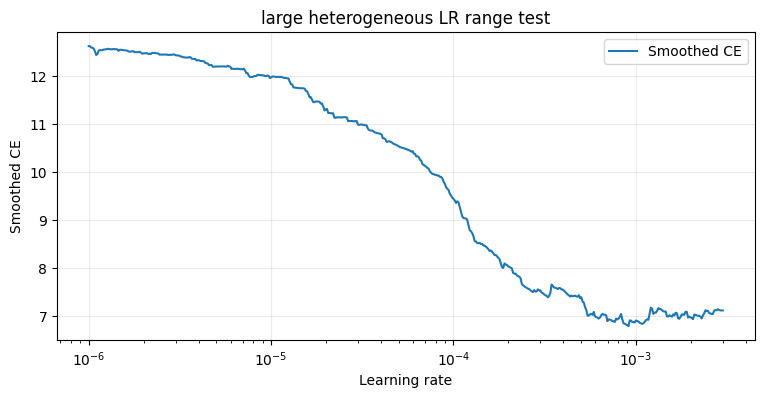

In [8]:
def run_lr_finder():
    assert LR_FINDER_STEPS >= 3 and 0 < LR_MIN < LR_MAX
    assert 0 <= LR_SMOOTH_BETA < 1
    history = {"lr": [], "loss": [], "smoothed_ce": [], "gradient_norm": [], "source": []}
    params = opt_state = step_fn = optimizer = prefetcher = batch = None
    try:
        # Locals own this entire temporary state; no run_state parameters are used.
        params = initialize_params(seed=INIT_SEED)
        def range_schedule(count):
            fraction = jnp.clip(count.astype(jnp.float32) / (LR_FINDER_STEPS - 1), 0.0, 1.0)
            return LR_MIN * jnp.exp(jnp.log(LR_MAX / LR_MIN) * fraction)
        optimizer = make_optimizer(range_schedule)
        opt_state = optimizer.init(params)
        step_fn = make_train_step(optimizer)
        prefetcher = HeterogeneousPrefetcher(
            num_workers=NUM_WORKERS, prefetch=PREFETCH_EXAMPLES, seed=LR_FINDER_SEED,
        )
        ema, best = 0.0, float("inf")
        started = time.perf_counter()
        for step in range(1, LR_FINDER_STEPS + 1):
            lr = float(LR_MIN * np.exp(np.log(LR_MAX / LR_MIN) * (step - 1) / (LR_FINDER_STEPS - 1)))
            example = prefetcher.next()
            batch = make_jax_batch(example)
            params, opt_state, loss, grad_norm = step_fn(params, opt_state, batch)
            loss, grad_norm = jax.block_until_ready((loss, grad_norm))
            loss_value, grad_value = float(loss), float(grad_norm)
            if not (np.isfinite(loss_value) and np.isfinite(grad_value)):
                print(f"LR finder stopped at step {step}: non-finite loss/gradient.")
                break
            ema = LR_SMOOTH_BETA * ema + (1.0 - LR_SMOOTH_BETA) * loss_value
            smoothed = ema / (1.0 - LR_SMOOTH_BETA ** step)
            history["lr"].append(lr)
            history["loss"].append(loss_value)
            history["smoothed_ce"].append(smoothed)
            history["gradient_norm"].append(grad_value)
            history["source"].append(example["source"])
            best = min(best, smoothed)
            if step == 1 or step % LR_LOG_EVERY == 0:
                speed = step / max(time.perf_counter() - started, 1e-9)
                print(f"LR test {step:4d}/{LR_FINDER_STEPS} | source={example['source']:6s} | "
                      f"lr={lr:.3e} | loss={loss_value:.5f} | smooth={smoothed:.5f} | "
                      f"gradient_norm={grad_value:.4f} | {speed:.3f} steps/sec")
            if step > 100 and smoothed > 1.5 * best:
                print("LR finder stopped: smoothed CE exceeded 1.5× its best value.")
                break
        # A completed donated update must finish before buffers are dropped.
        jax.block_until_ready((params, opt_state))
        return history
    finally:
        if prefetcher is not None:
            prefetcher.close()
        if step_fn is not None:
            step_fn.clear_cache()
        params = opt_state = step_fn = optimizer = prefetcher = batch = None
        gc.collect()
        jax.clear_caches()

if "run_state" in globals() or (RUN_DIR / "latest.json").exists():
    print("LR finder skipped: existing run detected; parameters and Adam moments will be restored.")
elif not RUN_LR_FINDER:
    print(f"LR finder disabled explicitly. Configured PEAK_LR={PEAK_LR:.3e} remains your choice.")
else:
    lr_finder_history = run_lr_finder()
    lr_values = np.asarray(lr_finder_history["lr"])
    smooth_values = np.asarray(lr_finder_history["smoothed_ce"])
    if len(lr_values) < 3:
        raise RuntimeError("Too few finite LR-finder updates; inspect the failure before training.")
    minimum_index = int(np.argmin(smooth_values))
    slopes = np.gradient(smooth_values, np.log10(lr_values))
    ignore = min(100, len(slopes) // 5)
    steepest_index = ignore + int(np.argmin(slopes[ignore:]))
    lr_finder_result = {
        "minimum_smoothed_ce": float(smooth_values[minimum_index]),
        "lr_at_minimum_smoothed_ce": float(lr_values[minimum_index]),
        "lr_at_steepest_descent": float(lr_values[steepest_index]),
        "steps": len(lr_values),
    }
    print(f"LR at minimum smoothed CE: {lr_values[minimum_index]:.3e} "
          f"(CE={smooth_values[minimum_index]:.5f})")
    print(f"LR at steepest descent:   {lr_values[steepest_index]:.3e}")
    print(f"PEAK_LR stays explicitly configured at {PEAK_LR:.3e}; "
          "edit it in the next cell after inspecting this model's curve.")
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(lr_values, smooth_values, label="Smoothed CE")
    ax.set(xscale="log", xlabel="Learning rate", ylabel="Smoothed CE",
           title=f"{MODEL_PRESET} heterogeneous LR range test")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()
    plt.close(fig)


### 9 · Real optimizer and schedule
`PEAK_LR` remains an explicit choice: the LR finder never sets it. Edit the assignment below after inspecting the plot. Linear warmup starts at zero; cosine decay reaches `FINAL_LR` on the last scheduled update. A checkpoint binds the schedule, model, and dataset identity; incompatible edits require a new `RUN_NAME`. This stage constructs the optimizer transformation only; stage 10 initializes or restores its state.

In [9]:
# Deliberate edit point after the LR finder. None uses stage 1's PEAK_LR.
PEAK_LR_OVERRIDE = 2e-4
if PEAK_LR_OVERRIDE is not None:
    PEAK_LR = float(PEAK_LR_OVERRIDE)
assert 0 < WARMUP_STEPS < TOTAL_TRAIN_STEPS - 1
assert 0 < FINAL_LR <= PEAK_LR
assert VALIDATE_EVERY > 0 and CHECKPOINT_EVERY > 0 and VAL_EXAMPLES_PER_SOURCE > 0

SCHEDULE_CONFIG = dict(total_steps=int(TOTAL_TRAIN_STEPS), warmup_steps=int(WARMUP_STEPS),
                       peak_lr=float(PEAK_LR), final_lr=float(FINAL_LR))

def make_lr_schedule(config):
    # Capture immutable Python numbers so later edits cannot change a compiled
    # optimizer's schedule without a compatibility check.
    total, warmup = config["total_steps"], config["warmup_steps"]
    peak, final = config["peak_lr"], config["final_lr"]
    def schedule(count):
        count = jnp.asarray(count, dtype=jnp.float32)
        warm = peak * count / warmup
        progress = jnp.clip((count - warmup) / (total - 1 - warmup), 0.0, 1.0)
        decay = final + 0.5 * (peak - final) * (1.0 + jnp.cos(jnp.pi * progress))
        return jnp.where(count < warmup, warm, decay)
    return schedule

lr_schedule = make_lr_schedule(SCHEDULE_CONFIG)
real_optimizer = make_optimizer(lr_schedule)
train_step = make_train_step(real_optimizer)

def current_lr(update_index):
    c = SCHEDULE_CONFIG
    if update_index < c["warmup_steps"]:
        return c["peak_lr"] * update_index / c["warmup_steps"]
    progress = min(1.0, max(0.0, (update_index - c["warmup_steps"]) /
                            (c["total_steps"] - 1 - c["warmup_steps"])))
    return c["final_lr"] + 0.5 * (c["peak_lr"] - c["final_lr"]) * (1 + math.cos(math.pi * progress))

print("Selected schedule:", SCHEDULE_CONFIG)
print("AdamW: beta1=.9, beta2=.95, eps=1e-8, clip=1.0, weight_decay=1e-10")
print("No real parameters or Adam buffers have been initialized in this stage.")


Selected schedule: {'total_steps': 1000000, 'warmup_steps': 10000, 'peak_lr': 0.0002, 'final_lr': 1e-06}
AdamW: beta1=.9, beta2=.95, eps=1e-8, clip=1.0, weight_decay=1e-10
No real parameters or Adam buffers have been initialized in this stage.


### 10 · Held-out evaluation and atomic checkpoints
Validation uses the same fixed seeded draws from each held-out source on every call (sampling with replacement), no gradients, and no optimizer calls. Each source contributes equally to macro CE. Checkpoints stream individual array leaves to disk, retaining parameters, Adam moments/count, step, histories, source counts, and the experiment contract. Atomic pointers identify `latest`, `previous`, and `best`; interrupted writes leave the last committed checkpoint intact. Restore validates checksums and restores the saved optimizer tree directly, without initializing Adam. Checkpoints are local trusted files from this notebook.

In [10]:
import pickle
import shutil
import tempfile
import uuid
from collections import deque
from concurrent.futures import ThreadPoolExecutor

def _sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for chunk in iter(lambda: f.read(8 * 1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def _canonical(value):
    return json.dumps(value, sort_keys=True, separators=(",", ":"), allow_nan=False)

def _code_fingerprint():
    # Persist the actual tested implementation files, not a mutable branch name.
    from openpi.models import gemma_fast, pi0_fast, siglip
    modules = [transforms, tokenizer, aloha_policy, droid_policy, gemma_fast, pi0_fast, siglip]
    return {m.__name__: _sha256_file(m.__file__) for m in modules}

EXPERIMENT_CONFIG = {
    "format_version": 1, "implementation": "heterogeneous-large-v1",
    "reference_sha256": "fc7570be1a775f318aa56b01a091cade938f63bb1acf32e7533386be2aa1a0d9",
    "model": model_config, "vocab_size": VOCAB_SIZE, "token_length": MAX_TOKEN_LEN,
    "image_size": MODEL_IMAGE_SIZE, "action_horizon": ACTION_HORIZON,
    "batch_size": BATCH_SIZE, "data_fingerprint": DATA_FINGERPRINT,
    "source_probabilities": dict(zip(sources, map(float, probabilities))),
    "train_seed": TRAIN_SEED, "init_seed": INIT_SEED, "embedding_seed": EMBED_SEED,
    "validation_seed": VAL_SEED, "validation_examples_per_source": VAL_EXAMPLES_PER_SOURCE,
    "schedule": SCHEDULE_CONFIG,
    "optimizer": dict(name="AdamW", b1=.9, b2=.95, eps=1e-8, clip=1.0, weight_decay=1e-10),
    "openpi_code": _code_fingerprint(),
    "jax_version": jax.__version__, "optax_version": optax.__version__,
}
CONFIG_FINGERPRINT = hashlib.sha256(_canonical(EXPERIMENT_CONFIG).encode()).hexdigest()
CHECKPOINT_ROOT = RUN_DIR / "checkpoints"
CHECKPOINT_ROOT.mkdir(exist_ok=True)

def _atomic_json(path, payload):
    path = Path(path)
    temporary = path.with_name(path.name + ".tmp-" + uuid.uuid4().hex)
    try:
        with temporary.open("w") as f:
            json.dump(payload, f, sort_keys=True, allow_nan=False)
            f.flush()
            os.fsync(f.fileno())
        os.replace(temporary, path)
        _fsync_directory(path.parent)
    finally:
        temporary.unlink(missing_ok=True)

def _fsync_directory(path):
    if os.name == "posix":
        fd = os.open(path, os.O_RDONLY)
        try:
            os.fsync(fd)
        finally:
            os.close(fd)

def _read_pointer(name):
    path = RUN_DIR / f"{name}.json"
    if not path.exists():
        return None
    pointer = json.loads(path.read_text())
    target = (CHECKPOINT_ROOT / pointer["directory"]).resolve()
    if target.parent != CHECKPOINT_ROOT.resolve():
        raise ValueError("Invalid checkpoint pointer path")
    return pointer

def _validate_state_metadata(metadata):
    if metadata["config_fingerprint"] != CONFIG_FINGERPRINT:
        raise ValueError("Checkpoint configuration differs. Restore its settings or use a new RUN_NAME; "
                         "Adam and the LR schedule will not be silently reset.")
    step = metadata["step"]
    assert step >= 0 and len(metadata["loss_history"]) == step
    assert len(metadata["grad_history"]) == step
    assert sum(metadata["source_counts"].values()) == step

def _prune_checkpoints():
    # Retain previous for recovery as well as latest and the best macro CE.
    keep = {p["directory"] for n in ("latest", "previous", "best") if (p := _read_pointer(n))}
    for path in CHECKPOINT_ROOT.glob("step_*"):
        if path.is_dir() and path.name not in keep:
            shutil.rmtree(path)

def _account_elapsed(state):
    if "_session_clock" in state:
        now = time.perf_counter()
        state["elapsed_train_seconds"] += now - state["_session_clock"]
        state["_session_clock"] = now

def save_checkpoint(state, is_best=False):
    if not state.get("valid", True):
        raise RuntimeError("The current donated buffers may be invalid; reload the committed checkpoint.")
    assert state["config_fingerprint"] == CONFIG_FINGERPRINT
    _account_elapsed(state)
    # The committed best pointer is authoritative even if interruption occurred
    # between publishing best and latest during a previous save.
    best_pointer = _read_pointer("best")
    disk_best = None if best_pointer is None else best_pointer["macro_val_ce"]
    candidate = (state["validation_history"][-1]["macro_val_ce"]
                 if state["validation_history"] and state["validation_history"][-1]["step"] == state["step"]
                 else None)
    is_best = candidate is not None and (disk_best is None or candidate < disk_best)
    state["best_macro_val_ce"] = min([x for x in (disk_best, candidate) if x is not None], default=None)
    metadata = {k: state[k] for k in ("step", "loss_history", "grad_history", "validation_history",
                                     "source_counts", "best_macro_val_ce", "elapsed_train_seconds",
                                     "config_fingerprint")}
    metadata["experiment_config"] = EXPERIMENT_CONFIG
    _validate_state_metadata(metadata)
    trees = [jax.tree_util.tree_flatten(state[k]) for k in ("params", "opt_state")]
    required = sum(int(x.size * x.dtype.itemsize) for leaves, _ in trees for x in leaves)
    if shutil.disk_usage(CHECKPOINT_ROOT).free < required + 512 * 1024**2:
        raise OSError(f"Checkpoint needs approximately {required / 1024**3:.2f} GiB of free space.")
    temporary = Path(tempfile.mkdtemp(prefix=".incomplete-", dir=CHECKPOINT_ROOT))
    committed = False
    try:
        structure_path = temporary / "structure.pkl"
        with structure_path.open("wb") as f:
            pickle.dump([treedef for _, treedef in trees], f, protocol=pickle.HIGHEST_PROTOCOL)
            f.flush(); os.fsync(f.fileno())
        metadata["structure_sha256"] = _sha256_file(structure_path)
        metadata["arrays"] = []
        for tree_index, (leaves, _) in enumerate(trees):
            records = []
            for leaf_index, leaf in enumerate(leaves):
                name = f"tree{tree_index}_{leaf_index:05d}.npy"
                # Stage one leaf explicitly per iteration; JAX may also retain
                # host caches (up to approximately one full checkpoint state).
                host_leaf = np.asarray(jax.device_get(leaf))
                # NumPy's .npy format otherwise stores bfloat16 as an opaque void
                # dtype; retain its exact bits and explicit logical dtype.
                encoded = host_leaf.view(np.uint16) if str(host_leaf.dtype) == "bfloat16" else host_leaf
                with (temporary / name).open("wb") as f:
                    np.save(f, encoded, allow_pickle=False)
                    f.flush(); os.fsync(f.fileno())
                records.append(dict(file=name, shape=list(host_leaf.shape), dtype=str(host_leaf.dtype),
                                    sha256=_sha256_file(temporary / name)))
                del host_leaf, encoded
            metadata["arrays"].append(records)
        _atomic_json(temporary / "metadata.json", metadata)
        name = f"step_{state['step']:012d}_{uuid.uuid4().hex[:8]}"
        destination = CHECKPOINT_ROOT / name
        os.replace(temporary, destination)
        _fsync_directory(CHECKPOINT_ROOT)
        pointer = dict(directory=name, step=state["step"],
                       metadata_sha256=_sha256_file(destination / "metadata.json"),
                       macro_val_ce=candidate)
        old = _read_pointer("latest")
        if old is not None:
            _atomic_json(RUN_DIR / "previous.json", old)
        # Publishing latest last means it always names a fully durable directory.
        if is_best:
            _atomic_json(RUN_DIR / "best.json", pointer)
        _atomic_json(RUN_DIR / "latest.json", pointer)
        committed = True
        try:
            _prune_checkpoints()
        except OSError as exc:
            print(f"Checkpoint saved; older checkpoint cleanup deferred: {exc}")
        print(f"Checkpoint committed: step={state['step']:,}" + (" [best macro CE]" if is_best else ""))
    finally:
        if not committed and temporary.exists():
            shutil.rmtree(temporary)

def restore_checkpoint(name="latest"):
    pointer = _read_pointer(name)
    if pointer is None:
        raise FileNotFoundError(RUN_DIR / f"{name}.json")
    directory = CHECKPOINT_ROOT / pointer["directory"]
    if _sha256_file(directory / "metadata.json") != pointer["metadata_sha256"]:
        raise ValueError("Checkpoint metadata checksum mismatch; previous.json is retained for recovery.")
    metadata = json.loads((directory / "metadata.json").read_text())
    _validate_state_metadata(metadata)
    if _sha256_file(directory / "structure.pkl") != metadata["structure_sha256"]:
        raise ValueError("Checkpoint tree structure checksum mismatch")
    # Validate every leaf before allocating GPU buffers.
    for records in metadata["arrays"]:
        for record in records:
            path = directory / record["file"]
            if path.parent != directory or _sha256_file(path) != record["sha256"]:
                raise ValueError(f"Corrupt checkpoint array: {record['file']}")
    with (directory / "structure.pkl").open("rb") as f:
        structures = pickle.load(f)
    trees = []
    for records, treedef in zip(metadata["arrays"], structures, strict=True):
        leaves = []
        for record in records:
            array = np.load(directory / record["file"], allow_pickle=False)
            if record["dtype"] == "bfloat16":
                array = array.view(jnp.bfloat16)
            assert list(array.shape) == record["shape"] and str(array.dtype) == record["dtype"]
            device_array = jax.device_put(array)
            device_array.block_until_ready()  # Bound host staging memory to one leaf.
            leaves.append(device_array)
            del array, device_array
        trees.append(jax.tree_util.tree_unflatten(treedef, leaves))
        del leaves
    state = {k: metadata[k] for k in ("step", "loss_history", "grad_history", "validation_history",
                                    "source_counts", "best_macro_val_ce", "elapsed_train_seconds",
                                    "config_fingerprint")}
    state.update(params=trees[0], opt_state=trees[1], valid=True)
    best_pointer = _read_pointer("best")
    if best_pointer is not None:
        state["best_macro_val_ce"] = best_pointer["macro_val_ce"]
    print(f"Restored {name}: {state['step']:,} steps; saved Adam moments and count preserved.")
    return state

def _validation_draw(source, draw_index):
    rng = np.random.default_rng(np.random.SeedSequence([VAL_SEED, sources.index(source), draw_index]))
    return sample_validation_example(rng, force_source=source)

def evaluate_held_out(params):
    result = {}
    for source in sources:
        values = []
        with ThreadPoolExecutor(max_workers=NUM_WORKERS) as pool:
            pending = deque(pool.submit(_validation_draw, source, i)
                            for i in list(range(min(PREFETCH_EXAMPLES, VAL_EXAMPLES_PER_SOURCE))))
            next_index = len(pending)
            while pending:
                example = pending.popleft().result()
                if next_index < VAL_EXAMPLES_PER_SOURCE:
                    pending.append(pool.submit(_validation_draw, source, next_index))
                    next_index += 1
                value = float(jax.block_until_ready(eval_step(params, make_jax_batch(example))))
                if not np.isfinite(value):
                    raise FloatingPointError(f"Nonfinite held-out CE for {source}")
                values.append(value)
        result[f"val/{source}_ce"] = float(np.mean(values))
    result["macro_val_ce"] = float(np.mean([result[f"val/{s}_ce"] for s in sources]))
    result["examples_per_source"] = VAL_EXAMPLES_PER_SOURCE
    print(" | ".join(f"{k}={v:.5f}" for k, v in result.items() if k != "examples_per_source"))
    return result

def validate_and_checkpoint(state):
    record = dict(step=state["step"], **evaluate_held_out(state["params"]))
    previous_best = state["best_macro_val_ce"]
    improved = previous_best is None or record["macro_val_ce"] < previous_best
    state["validation_history"].append(record)
    try:
        save_checkpoint(state, is_best=improved)
    except BaseException:
        state["validation_history"].pop()
        state["best_macro_val_ce"] = previous_best
        raise
    return record

if "run_state" in globals():
    assert run_state.get("valid", False), "Restart the kernel and restore latest; buffers may be invalid."
    assert run_state["config_fingerprint"] == CONFIG_FINGERPRINT, "Live run settings differ."
    print("Keeping in-memory parameters and Adam state at step", run_state["step"])
elif (RUN_DIR / "latest.json").exists():
    run_state = restore_checkpoint()
else:
    assert globals().get("SMOKE_TEST_PASSED", False), "Complete the fresh-model smoke test first."
    # The only real initialization site. LR-finder params never leave their function.
    _initial_params = initialize_params(seed=INIT_SEED, embedding_seed=EMBED_SEED)
    run_state = dict(params=_initial_params, opt_state=real_optimizer.init(_initial_params),
                     step=0, loss_history=[], grad_history=[], validation_history=[],
                     source_counts={s: 0 for s in sources}, best_macro_val_ce=None,
                     elapsed_train_seconds=0.0, config_fingerprint=CONFIG_FINGERPRINT, valid=True)
    del _initial_params
    save_checkpoint(run_state)
print(f"Held-out evaluation: {VAL_EXAMPLES_PER_SOURCE} fixed seeded examples per source; equal-source macro CE.")


Checkpoint committed: step=0
Held-out evaluation: 128 fixed seeded examples per source; equal-source macro CE.


### 11 · Overnight training
Rerunning this cell continues the existing state. The indexed prefetcher starts at the completed step, so changing workers or queue depth preserves sample order. The graph has exactly one line: the 100-step rolling training CE. Logs include pre-clipping gradient norm and the LR used for that update. Validation improvements save `best`; scheduled saves and clean pauses save `latest`. The 10-hour budget is a configurable session pause, independent of the step budget; it is checked between updates and may overrun during compilation, validation, or checkpoint writes. After a device error or an interruption during a donated update, restart the kernel and restore the committed checkpoint.

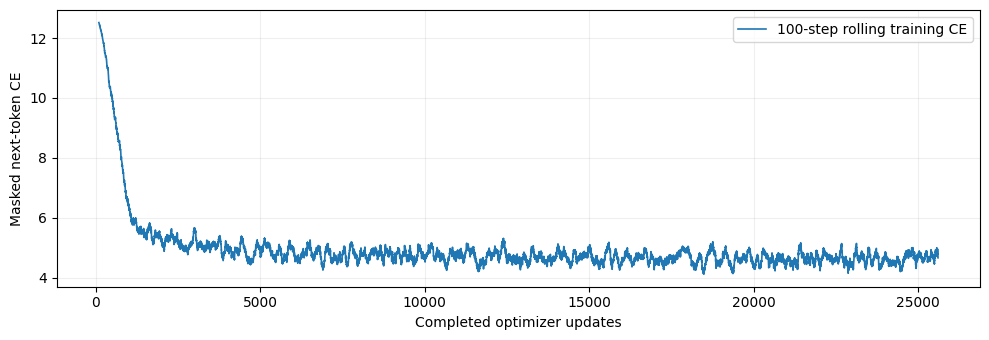

step=1 | source=aloha  | loss=12.55153 | avg100=12.55153 | lr=0.000e+00 | grad=12.7503 | 0.124 steps/s
step=100 | source=coco   | loss=12.56077 | avg100=12.51794 | lr=1.980e-06 | grad=20.8593 | 6.710 steps/s
step=200 | source=aloha  | loss=11.91071 | avg100=12.08318 | lr=3.980e-06 | grad=9.7142 | 6.433 steps/s
step=300 | source=coco   | loss=11.98635 | avg100=11.42044 | lr=5.980e-06 | grad=20.1128 | 6.484 steps/s
step=400 | source=aloha  | loss=10.93399 | avg100=10.58714 | lr=7.980e-06 | grad=8.5850 | 6.383 steps/s
step=500 | source=coco   | loss=10.71243 | avg100=10.04541 | lr=9.980e-06 | grad=12.6915 | 6.455 steps/s
step=600 | source=vqav2  | loss=6.90142 | avg100=9.29866 | lr=1.198e-05 | grad=92.8722 | 6.425 steps/s
step=700 | source=coco   | loss=8.84883 | avg100=8.55783 | lr=1.398e-05 | grad=10.5330 | 6.619 steps/s
step=800 | source=aloha  | loss=7.52122 | avg100=7.85138 | lr=1.598e-05 | grad=7.3462 | 6.316 steps/s
step=900 | source=droid  | loss=6.52117 | avg100=7.00113 | lr=1.79

step=6,600 | source=aloha  | loss=5.30714 | avg100=4.73459 | lr=1.320e-04 | grad=4.3053 | 6.407 steps/s
step=6,700 | source=droid  | loss=4.83159 | avg100=4.83675 | lr=1.340e-04 | grad=3.2971 | 6.648 steps/s
step=6,800 | source=droid  | loss=4.43240 | avg100=4.97258 | lr=1.360e-04 | grad=3.5975 | 6.331 steps/s
step=6,900 | source=vqav2  | loss=1.82781 | avg100=4.33772 | lr=1.380e-04 | grad=14.9817 | 6.066 steps/s
step=7,000 | source=aloha  | loss=4.44719 | avg100=5.02737 | lr=1.400e-04 | grad=4.8270 | 6.466 steps/s
step=7,100 | source=vqav2  | loss=1.35061 | avg100=4.75356 | lr=1.420e-04 | grad=19.7988 | 6.428 steps/s
step=7,200 | source=droid  | loss=5.10276 | avg100=4.65152 | lr=1.440e-04 | grad=4.2398 | 6.490 steps/s
step=7,300 | source=aloha  | loss=4.27640 | avg100=4.67771 | lr=1.460e-04 | grad=4.4778 | 6.295 steps/s
step=7,400 | source=vqav2  | loss=7.26009 | avg100=4.66962 | lr=1.480e-04 | grad=17.6190 | 6.427 steps/s
step=7,500 | source=droid  | loss=4.95358 | avg100=4.75141 | 

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

val/aloha_ce=4.69220 | val/droid_ce=4.70088 | val/coco_ce=6.02250 | val/vqav2_ce=4.32633 | macro_val_ce=4.93548
Checkpoint committed: step=10,000 [best macro CE]
step=10,100 | source=aloha  | loss=5.54886 | avg100=4.82515 | lr=2.000e-04 | grad=4.8183 | 1.459 steps/s
step=10,200 | source=aloha  | loss=5.03811 | avg100=5.13555 | lr=2.000e-04 | grad=4.3226 | 6.652 steps/s
step=10,300 | source=coco   | loss=8.52348 | avg100=4.64114 | lr=2.000e-04 | grad=10.3334 | 6.394 steps/s
step=10,400 | source=aloha  | loss=4.76785 | avg100=4.71711 | lr=2.000e-04 | grad=4.4632 | 6.595 steps/s
step=10,500 | source=droid  | loss=4.54415 | avg100=4.77471 | lr=2.000e-04 | grad=3.4904 | 6.373 steps/s
step=10,600 | source=droid  | loss=4.68613 | avg100=4.62444 | lr=2.000e-04 | grad=4.0440 | 6.525 steps/s
step=10,700 | source=coco   | loss=5.13302 | avg100=4.41417 | lr=2.000e-04 | grad=8.9114 | 6.445 steps/s
step=10,800 | source=aloha  | loss=5.22293 | avg100=4.88587 | lr=2.000e-04 | grad=5.3510 | 6.386 steps

step=23,400 | source=aloha  | loss=4.20192 | avg100=4.26862 | lr=1.999e-04 | grad=63.5643 | 6.792 steps/s
step=23,500 | source=vqav2  | loss=1.38796 | avg100=4.97529 | lr=1.999e-04 | grad=54.4518 | 6.320 steps/s
step=23,600 | source=vqav2  | loss=1.11207 | avg100=4.42242 | lr=1.999e-04 | grad=21.6050 | 6.878 steps/s
step=23,700 | source=aloha  | loss=4.02004 | avg100=4.85896 | lr=1.999e-04 | grad=5.9604 | 6.562 steps/s
step=23,800 | source=droid  | loss=4.59457 | avg100=4.41663 | lr=1.999e-04 | grad=6.2156 | 6.544 steps/s
step=23,900 | source=aloha  | loss=4.03773 | avg100=4.43892 | lr=1.999e-04 | grad=6.1791 | 6.493 steps/s
step=24,000 | source=coco   | loss=5.01332 | avg100=4.85793 | lr=1.999e-04 | grad=11.5587 | 6.890 steps/s
step=24,100 | source=coco   | loss=6.12618 | avg100=4.40848 | lr=1.999e-04 | grad=12.2627 | 6.268 steps/s
step=24,200 | source=vqav2  | loss=6.78049 | avg100=4.50206 | lr=1.999e-04 | grad=18.6712 | 6.620 steps/s
step=24,300 | source=vqav2  | loss=1.65333 | avg1

In [ ]:
def plot_rolling_ce(losses, handle=None):
    fig, ax = plt.subplots(figsize=(10, 3.5))
    values = np.asarray(losses, dtype=np.float64)
    if len(values) >= ROLLING_WINDOW:
        cumulative = np.concatenate(([0.0], np.cumsum(values)))
        rolling = (cumulative[ROLLING_WINDOW:] - cumulative[:-ROLLING_WINDOW]) / ROLLING_WINDOW
        ax.plot(np.arange(ROLLING_WINDOW, len(values) + 1), rolling,
                linewidth=1.2, label="100-step rolling training CE")
        ax.legend(loc="upper right")
    ax.set(xlabel="Completed optimizer updates", ylabel="Masked next-token CE")
    ax.grid(alpha=.2)
    fig.tight_layout()
    if handle is None:
        handle = display(fig, display_id=True)
    else:
        handle.update(fig)
    plt.close(fig)
    return handle

assert run_state.get("valid", False), "Restart the kernel and restore the last checkpoint."
assert run_state["config_fingerprint"] == CONFIG_FINGERPRINT
assert SCHEDULE_CONFIG == dict(total_steps=TOTAL_TRAIN_STEPS, warmup_steps=WARMUP_STEPS,
                              peak_lr=PEAK_LR, final_lr=FINAL_LR), "Rerun stage 9/10 after config edits."
assert SCHEDULE_CONFIG == EXPERIMENT_CONFIG["schedule"], "Run stage 10 to validate the changed schedule."
_start_step = run_state["step"]
_session_start = time.perf_counter()
run_state["_session_clock"] = _session_start
_last_log_time, _last_log_step = _session_start, _start_step
_graph = plot_rolling_ce(run_state["loss_history"])
_loader = None
_inside_update = False
_normal_exit = False
try:
    if run_state["step"] < TOTAL_TRAIN_STEPS:
        _loader = HeterogeneousPrefetcher(num_workers=NUM_WORKERS, prefetch=PREFETCH_EXAMPLES,
                                         seed=TRAIN_SEED, start_index=run_state["step"])
    while run_state["step"] < TOTAL_TRAIN_STEPS:
        if MAX_RUN_HOURS is not None and time.perf_counter() - _session_start >= MAX_RUN_HOURS * 3600:
            print("Session wall-clock budget reached; saving a resumable pause.")
            break
        _example = _loader.next()
        _source = _example["source"]
        _batch = make_jax_batch(_example)
        _used_lr = current_lr(run_state["step"])
        _inside_update = True
        # Direct replacement avoids an extra reference to donated parameter buffers.
        (run_state["params"], run_state["opt_state"], _loss, _grad) = train_step(
            run_state["params"], run_state["opt_state"], _batch)
        _loss, _grad = jax.block_until_ready((_loss, _grad))
        _loss_value, _grad_value = float(_loss), float(_grad)
        if not np.isfinite(_loss_value) or not np.isfinite(_grad_value):
            raise FloatingPointError("Nonfinite training metrics; preserving the last committed checkpoint.")
        run_state["step"] += 1
        run_state["loss_history"].append(_loss_value)
        run_state["grad_history"].append(_grad_value)
        run_state["source_counts"][_source] += 1
        _inside_update = False
        _step = run_state["step"]
        if _step % LOG_EVERY == 0 or _step == _start_step + 1:
            _now = time.perf_counter()
            _speed = (_step - _last_log_step) / max(_now - _last_log_time, 1e-9)
            _avg = float(np.mean(run_state["loss_history"][-ROLLING_WINDOW:]))
            print(f"step={_step:,} | source={_source:6s} | loss={_loss_value:.5f} | "
                  f"avg100={_avg:.5f} | lr={_used_lr:.3e} | grad={_grad_value:.4f} | {_speed:.3f} steps/s")
            _last_log_time, _last_log_step = _now, _step
        if _step % PLOT_EVERY == 0:
            _graph = plot_rolling_ce(run_state["loss_history"], _graph)
        if _step % VALIDATE_EVERY == 0:
            validate_and_checkpoint(run_state)
        elif _step % CHECKPOINT_EVERY == 0:
            save_checkpoint(run_state)
    _normal_exit = True
except KeyboardInterrupt:
    if _inside_update:
        run_state["valid"] = False
        print("Interrupted during a donated update. Restart the kernel to resume the committed checkpoint.")
    else:
        print("Paused between updates; saving the current state.")
        save_checkpoint(run_state)
except BaseException:
    if _inside_update:
        run_state["valid"] = False
    print("Run stopped. The last committed checkpoint remains available; no failed update is saved.")
    raise
finally:
    if _loader is not None:
        _loader.close()
    _account_elapsed(run_state)
    run_state.pop("_session_clock", None)
    _loader = None

if _normal_exit:
    # One final evaluation at the paused/finished step; do not duplicate a periodic evaluation.
    if not run_state["validation_history"] or run_state["validation_history"][-1]["step"] != run_state["step"]:
        validate_and_checkpoint(run_state)
    else:
        save_checkpoint(run_state)
    _graph = plot_rolling_ce(run_state["loss_history"], _graph)
    print(f"Session completed {run_state['step'] - _start_step:,} updates; total={run_state['step']:,}.")


### 12 · Final summary
Metrics below describe the current checkpoint. `best.json` points to the lowest observed equal-source macro validation CE; it need not be the latest step. CE measures teacher-forced token prediction and does not establish closed-loop robot success. The only training curve is the 100-step rolling mean.

In [ ]:
assert run_state.get("valid", False), "Restore a committed checkpoint before summarizing."
if not run_state["validation_history"] or run_state["validation_history"][-1]["step"] != run_state["step"]:
    validate_and_checkpoint(run_state)
last_validation = run_state["validation_history"][-1]
summary = dict(step=run_state["step"], model=model_config,
               parameters=sum(int(x.size) for x in jax.tree_util.tree_leaves(run_state["params"])),
               source_counts=run_state["source_counts"],
               avg100=float(np.mean(run_state["loss_history"][-100:])) if run_state["loss_history"] else None,
               last_validation=last_validation, best_macro_val_ce=run_state["best_macro_val_ce"],
               schedule=SCHEDULE_CONFIG, latest=_read_pointer("latest"), best=_read_pointer("best"))
_atomic_json(RUN_DIR / "summary.json", summary)
print(json.dumps(summary, indent=2))
_final_graph = plot_rolling_ce(run_state["loss_history"])
